# Entrega PDEs 22/09/2026
### Brais Otero Lema

PDEs 1. Exercise 1: Run 50 Jacobi iterations and plot the result. Show the maximum change in values after 50 iterations. Run an example where you setup a tolerance for the loop to stop.

 54%|█████▍    | 27/50 [00:00<00:00, 32551.37it/s]

Maximum change after 28 steps: 0.527


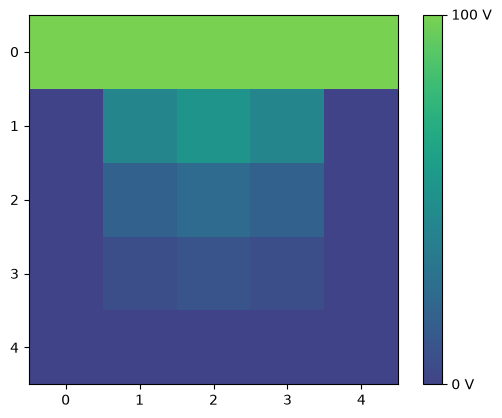

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from cmasher import get_sub_cmap
from tqdm import tqdm
from matplotlib.ticker import FixedFormatter

def jacobi_step(V):
    V_new = V.copy()
    V_new[1:-1, 1:-1] = .25 * (V[1:-1, :-2] + V[1:-1, 2:] + V[:-2, 1:-1] + V[2:, 1:-1])
    return V_new

maximum_steps = 50
tolerance = 1e-5

side = 5
V_initial = np.zeros((side, side))
V_initial[0,:] = 1

V_prev = V_initial

for step in tqdm(range(maximum_steps)):

    V_step = jacobi_step(V_prev)

    below_tolerance = np.all(np.abs(V_step - V_prev) < tolerance)
    if not below_tolerance:
        V_prev = V_step
    else:
        break

maximum_change = np.max(np.abs(V_step - V_initial))
print(f"Maximum change after {step+1} steps: {maximum_change:.3f}")

fig, ax = plt.subplots()

cax = ax.imshow(V_step, cmap=get_sub_cmap("viridis", .2, .8))

ax.set_xticks(np.arange(side))
ax.set_yticks(np.arange(side))

ax.set_xticklabels(np.arange(side))
ax.set_yticklabels(np.arange(side))

fig.colorbar(cax, ax=ax, location="right", orientation="vertical", fraction=.1, ticks=[cax.norm.vmin, cax.norm.vmax], format=FixedFormatter([r"$0$ V", r"$100$ V"]))


PDEs 1. Exercise 2: Convergence & Grid Refinement. We will perform a refinement study using Laplace's equation on the unit square with these boundary conditions:

$$
V(x,0) = 0, \quad V(x,1) = \sin(\pi x), \quad V(0,y) = 0, \quad V(1,y) = 0.
$$

This problem has the exact solution: $V(x,y) = \dfrac{\sin(\pi x)\sinh(\pi y)}{\sinh(\pi)}.$

Solve the problem numerically using the Gauss–Seidel method on grids of size $10\times 10$, $20\times 20$, $40\times 40$, $80\times 80$ and $120\times 120$. Compare each numerical solution to the analytic one by interpolating both to the same mesh and computing the maximum error. Plot the maximum error versus grid size.

 96%|█████████▌| 14357/15000 [00:00<00:00, 16050.28it/s]


Text(0, 0.5, 'Maximum absolute error')

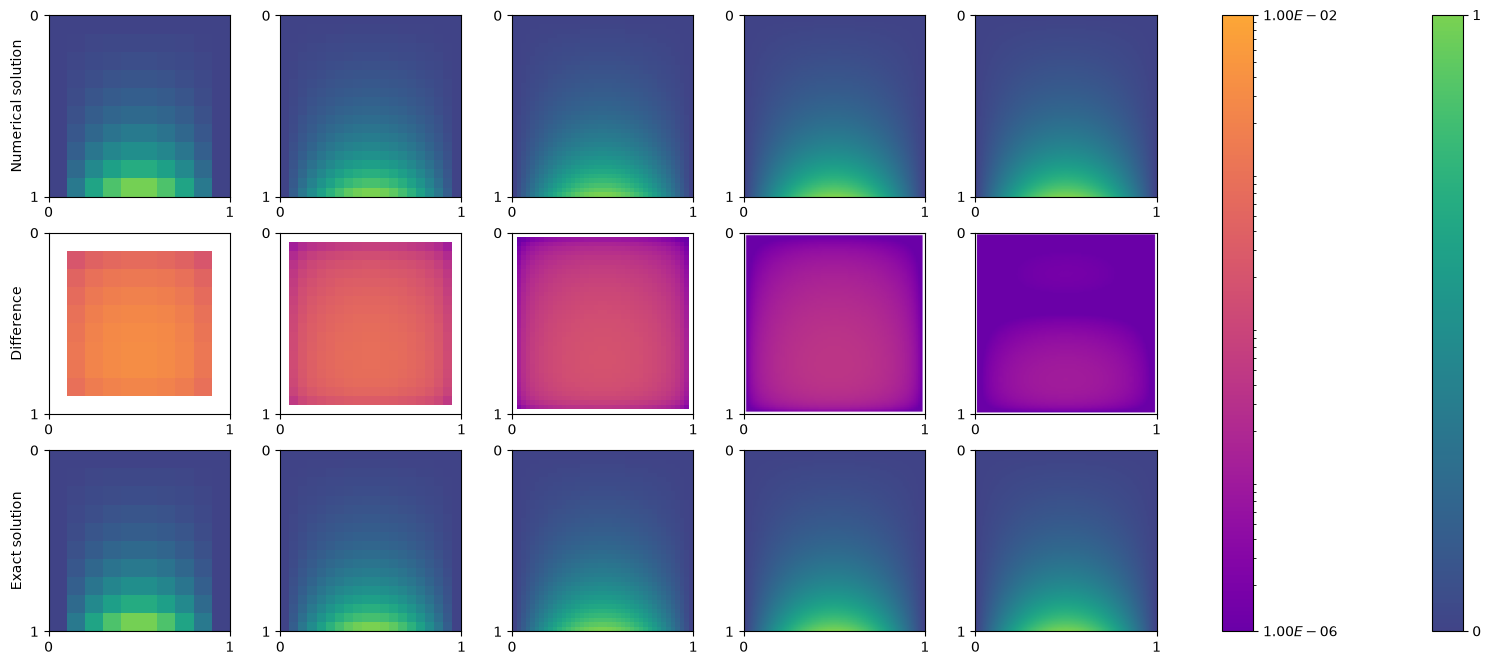

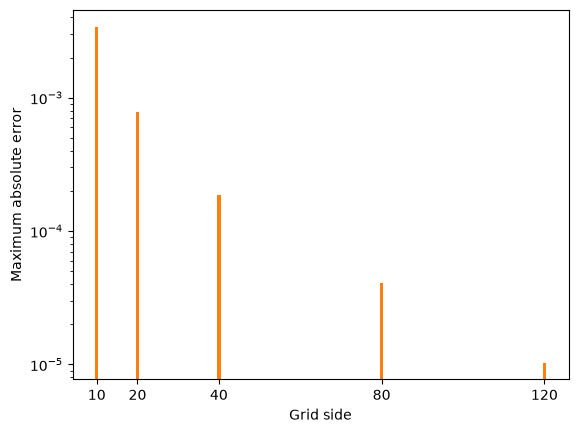

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from cmasher import get_sub_cmap
from matplotlib.ticker import FixedFormatter
from matplotlib.colors import Normalize, LogNorm
from matplotlib.colorizer import Colorizer

def get_boundary(side):
    V = np.zeros((side, side))
    boundary_mask = np.zeros_like(V, dtype=bool)
    boundary_values = np.zeros_like(V)

    boundary_mask[:,0] = True
    boundary_mask[0,:] = True
    boundary_mask[:,-1] = True

    V[-1,:] = np.sin(np.pi * np.linspace(0, 1, side))
    boundary_mask[-1,:] = True
    boundary_values[-1,:] = V.copy()[-1,:]

    return V, boundary_mask, boundary_values

def gauss_seidel_rb_step(V, mask, mask_values):
    V[1:-1:2,1:-1:2] = 0.25*(
        V[:-2:2,1:-1:2] + V[2::2,1:-1:2] +
        V[1:-1:2,:-2:2] + V[1:-1:2,2::2]
    )
    V[2:-1:2,2:-1:2] = 0.25*(
        V[1:-2:2,2:-1:2] + V[3::2,2:-1:2] +
        V[2:-1:2,1:-2:2] + V[2:-1:2,3::2]
    )

    V[2:-1:2,1:-1:2] = 0.25*(
        V[1:-2:2,1:-1:2] + V[3::2,1:-1:2] +
        V[2:-1:2,:-2:2] + V[2:-1:2,2::2]
    )
    V[1:-1:2,2:-1:2] = 0.25*(
        V[:-2:2,2:-1:2] + V[2::2,2:-1:2] +
        V[1:-1:2,1:-2:2] + V[1:-1:2,3::2]
    )

    V[mask] = mask_values[mask]
    return V

exact = lambda x, y : np.sin(np.pi*x) * np.sinh(np.pi*y) / np.sinh(np.pi)

tolerance = 1e-8
maximum_steps = 15_000

sides = (10, 20, 40, 80, 120)
fig, axs = plt.subplots(3, len(sides), figsize=(20, 8))
maximum_errors = np.zeros_like(sides, dtype=np.float64)

vir_norm = Normalize(vmin=0, vmax=1)
vir_colorizer = Colorizer(norm=vir_norm, cmap=get_sub_cmap("viridis", .2, .8))

pla_norm = LogNorm(vmin=1e-6, vmax=1e-2)
pla_colorizer = Colorizer(norm=pla_norm, cmap=get_sub_cmap("plasma", .2, .8))

for i, side in enumerate(sides):

    V_initial, boundary_mask, boundary_values = get_boundary(side)
    V_prev = V_initial.copy()

    for step in tqdm(range(maximum_steps)):
        V_check = V_prev.copy()
        V_step = gauss_seidel_rb_step(V_prev, boundary_mask, boundary_values)

        below_tolerance = np.all(np.abs(V_step - V_check) < tolerance)
        if not below_tolerance:
            V_prev = V_step.copy()
        else:
            break

    side_values = np.linspace(0, 1, side)
    grid_values_x, grid_values_y = np.meshgrid(side_values, side_values)

    V_exact = exact(grid_values_x, grid_values_y)
    V_exact[boundary_mask] = boundary_values[boundary_mask]
    V_error = np.abs(V_step[1:-1,1:-1] - V_exact[1:-1,1:-1])
    maximum_errors[i] = np.max(V_error)

    numerical_ax = axs[0,i]
    vcax = numerical_ax.imshow(V_step, colorizer=vir_colorizer)
    if i == 0: numerical_ax.set_ylabel("Numerical solution")

    difference_ax = axs[1,i]
    pcax = difference_ax.imshow(np.abs(V_step - V_exact), colorizer=pla_colorizer)
    if i == 0: difference_ax.set_ylabel("Difference")

    exact_ax = axs[2,i]
    exact_ax.imshow(V_exact, colorizer=vir_colorizer)
    if i == 0: exact_ax.set_ylabel("Exact solution")

    for ax in (numerical_ax, exact_ax, difference_ax):
        ax.set_xticks([-.5, side-.5])
        ax.set_yticks([-.5, side-.5])
    
        ax.set_xticklabels(["0", "1"])
        ax.set_yticklabels(["0", "1"])

fig.colorbar(vcax, ax=axs, location="right", orientation="vertical", fraction=.1, ticks=[vir_norm.vmin, vir_norm.vmax], format=FixedFormatter([r"$0$", r"$1$"]))

fig.colorbar(pcax, ax=axs, location="right", orientation="vertical", fraction=.1, ticks=[pla_norm.vmin, pla_norm.vmax], format=FixedFormatter([f"${pla_norm.vmin:.2E}$", f"${pla_norm.vmax:.2E}$"]))

fig, ax = plt.subplots()

ax.bar(sides, maximum_errors, color="tab:orange")

ax.set_yscale("log")

ax.set_xticks(sides)

ax.set_xlabel("Grid side")
ax.set_ylabel("Maximum absolute error")


PDEs 1. Exercise 3. Compute the electrostatic potential inside a square domain (charge-free) whose top side is a conductor at 100 V and the other three sides are grounded (0 V). Use a 40×40 grid. Compare Jacobi and Gauss–Seidel convergence. Include equipotential contour plots.

 38%|███▊      | 1921/5000 [00:00<00:00, 55401.86it/s]


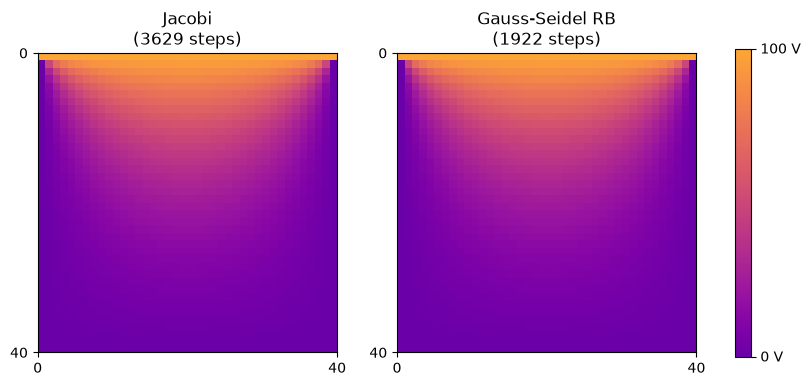

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from cmasher import get_sub_cmap
from matplotlib.ticker import FixedFormatter

def get_boundary(side):
    V = np.zeros((side, side))
    boundary_mask = np.zeros_like(V, dtype=bool)
    boundary_values = np.zeros_like(V)

    boundary_mask[:,0] = True
    boundary_mask[-1,:] = True
    boundary_mask[:,-1] = True

    V[0,:] = 1
    boundary_mask[0,:] = True
    boundary_values[0,:] = V.copy()[0,:]

    return V, boundary_mask, boundary_values

def gauss_seidel_rb_step(V, mask, mask_values):
    V[1:-1:2,1:-1:2] = 0.25*(
        V[:-2:2,1:-1:2] + V[2::2,1:-1:2] +
        V[1:-1:2,:-2:2] + V[1:-1:2,2::2]
    )
    V[2:-1:2,2:-1:2] = 0.25*(
        V[1:-2:2,2:-1:2] + V[3::2,2:-1:2] +
        V[2:-1:2,1:-2:2] + V[2:-1:2,3::2]
    )

    V[2:-1:2,1:-1:2] = 0.25*(
        V[1:-2:2,1:-1:2] + V[3::2,1:-1:2] +
        V[2:-1:2,:-2:2] + V[2:-1:2,2::2]
    )
    V[1:-1:2,2:-1:2] = 0.25*(
        V[:-2:2,2:-1:2] + V[2::2,2:-1:2] +
        V[1:-1:2,1:-2:2] + V[1:-1:2,3::2]
    )

    V[mask] = mask_values[mask]
    return V

def jacobi_step(V, mask, mask_values):
    V_new = V.copy()
    V_new[1:-1, 1:-1] = .25 * (V[1:-1, :-2] + V[1:-1, 2:] + V[:-2, 1:-1] + V[2:, 1:-1])
    return V_new

tolerance = 1e-8
maximum_steps = 5000
side = 40

fig, axs = plt.subplots(1, 2, figsize=(10,4))
methods = (jacobi_step, gauss_seidel_rb_step)
titles = ("Jacobi", "Gauss-Seidel RB")

for ax, method, title in zip(axs, methods, titles):

    V_initial, boundary_mask, boundary_values = get_boundary(side)
    V_prev = V_initial.copy()

    for step in tqdm(range(maximum_steps)):
        V_check = V_prev.copy()
        V_step = method(V_prev, boundary_mask, boundary_values)

        below_tolerance = np.all(np.abs(V_step - V_check) < tolerance)
        if not below_tolerance:
            V_prev = V_step.copy()
        else:
            break

    cax = ax.imshow(V_step, cmap=get_sub_cmap("plasma", .2, .8))

    ax.set_xticks([-.5, side-.5])
    ax.set_yticks([-.5, side-.5])

    ax.set_xticklabels(["0", "40"])
    ax.set_yticklabels(["0", "40"])

    ax.set_title(f"{title}\n({step+1} steps)")

fig.colorbar(cax, ax=axs, orientation="vertical", fraction=.1, ticks=[cax.norm.vmin, cax.norm.vmax], format=FixedFormatter([r"$0$ V", r"$100$ V"]))


PDEs 2. Exercise 1: Study heat diffusion with a mixed boundary condition. Consider the same one-dimensional insulated rod, but now the left end of the rod is held at $T = 0$ and the right end of the rod is insulated, so there is no heat flow through it. The initial temperature insde the rod is 100°C. Mathematically, this means

$$
\dfrac{\partial T}{\partial x}\bigg|_{x=L} = 0.
$$

Implement the FTCS method for this system. Compare temperature profiles for stable and unstable time steps.
Observe how the insulated boundary condition affects the shape of the solution compared to the fully fixed case.

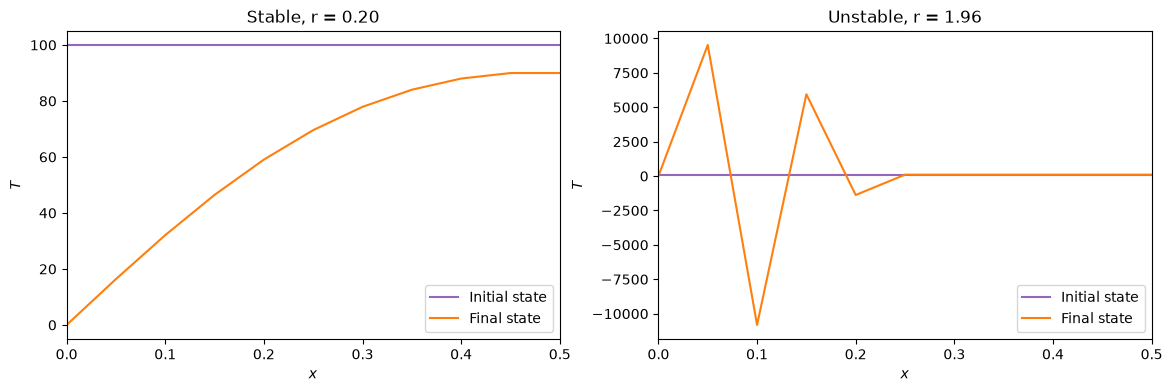

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def ftcs_step(T, r, step):
    T[step+1, 1:-1] = T[step, 1:-1] + r * (T[step, 2:] + T[step, :-2] - 2*T[step, 1:-1])
    return T

L, timelength, c2 = .5, .6, .049
N = 11

dx = L / (N-1)
xlin = np.linspace(0, L, N)

dts = (1e-2, 1e-1)
titles = ("Stable", "Unstable")
fig, axs = plt.subplots(1, 2, figsize=(14, 4))

for (dt, title, ax) in zip(dts, titles, axs):

    timesteps = 1 + int(timelength/dt)

    r = c2 * dt / dx**2

    T_initial = np.zeros((timesteps, N))
    T_initial[0, :] = 100

    T_step = T_initial.copy()
    for timestep in range(timesteps-1):
        T_step = ftcs_step(T_step, r, timestep)
        T_step[timestep+1, -1] = T_step[timestep+1, -2]

    ax.plot(xlin, T_initial[0, :], ls="solid", color="tab:purple", label="Initial state")
    ax.plot(xlin, T_step[-1, :], ls="solid", color="tab:orange", label="Final state")

    ax.set_xlim(left=np.min(xlin), right=np.max(xlin))

    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$T$")

    ax.legend(loc="lower right")

    ax.set_title(f"{title}, r = {r:.2f}")


PDEs 2. Exercise 2: Solve the 1D wave equation on the domain $0 \leq x \leq 1,$ $0 \leq t \leq 0.5,$ with $c = 1.0 \text{m/s}$ and fixed ends

$$
y(0,t) = y(1,t) = 0 \quad \text{for } 0 \leq t \leq 0.5.
$$

Initial conditions:

- Localized displacement (Gaussian "pluck") centered at $x_0 = 0.5$:

$$
y(x,0) = f(x) = \exp{\left(-\dfrac{(x-x_0)^2}{2\sigma^2}\right)}
$$

with $\sigma = 0.05$.

- Small initial velocity:

$$
\dfrac{\partial y(x,0)}{\partial t} = g(x) = 0.2\sin(\pi x).
$$

Use $\Delta x = 0.01$ and $\Delta t = 0.005$.

Compute the Courant number $r = c\Delta t / \Delta x$ and verify stability. Initialize the solution (use the second-order Taylor formula to set the $j=1$ row). March the solution to $t = 0.5$ and plot snapshots of $y(x,t)$ at $t = 0, 0.125, 0.25, 0.375, 0.5$. Try a larger $\Delta t$ (e.g. $\Delta t = 0.01$) and observe what happens.

<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_14020/2588770755.py:57: SyntaxWarning: invalid escape sequence '\D'
  ax.set_title(f"$\Delta t = {dt}$ s")


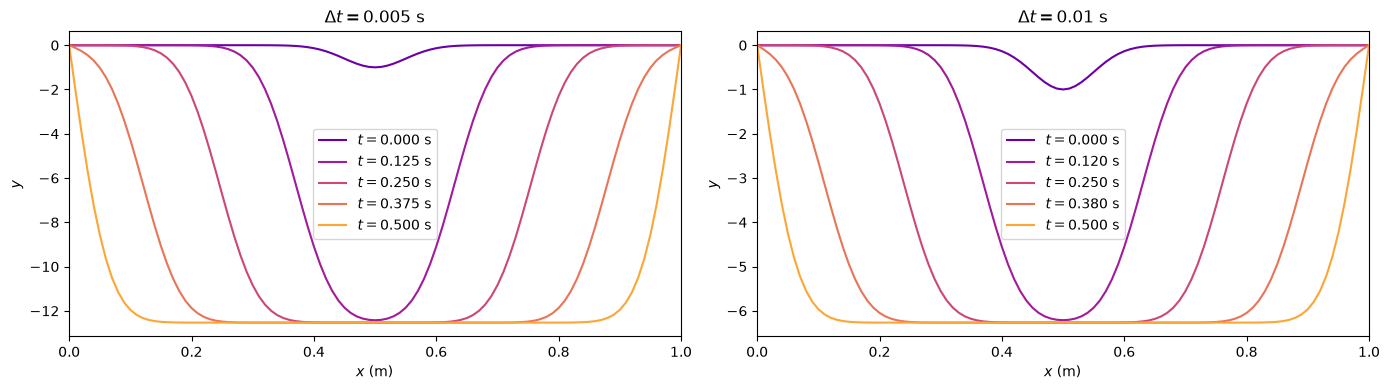

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from cmasher import get_sub_cmap

def wave_step(y_now, y_past, r):
    y_next = np.zeros_like(y_now)
    y_next[1:-1] = 2*y_now[1:-1] - y_past[1:-1] + r**2 * (y_now[2:] + y_now[:-2] - 2*y_now[1:-1])
    return y_now, y_next

L, timelength, c = 1, .5, 1
x0, sigma = .5, .05

boundary_f = lambda x : np.exp(-(x - x0)**2/2/sigma**2)
boundary_g = lambda x : -2*np.sin(np.pi * x)

dx = .01
N = 1 + int(round(L / dx))
xlin = np.linspace(0, L, N)

snapshot_times = (0, .125, .25, .375, .5)

dts = (.005, .01)
fig, axs = plt.subplots(1, 2, figsize=(14,4))

for (dt, ax) in zip(dts, axs):

    timesteps = 1 + int(timelength/dt)

    r = c * dt / dx

    y_past = boundary_f(xlin)
    y_now = np.zeros_like(y_past)

    snapshot_steps = [int(round(time / dt)) for time in snapshot_times]

    snapshots = {
        0.0 : y_past.copy()
    }

    for timestep in range(timesteps):
        y_past, y_now = wave_step(y_now, y_past, r)

        if timestep in snapshot_steps:
            snapshots[round(timestep * dt, 6)] = y_now.copy()

    snapshot_colors = [c for c in get_sub_cmap("plasma", .2, .8, N=len(list(snapshots.keys()))).colors]
    for (time, snapshot, snap_color) in zip(list(snapshots.keys()), list(snapshots.values()), snapshot_colors):
        ax.plot(xlin, snapshot, ls="solid", color=snap_color, label=f"$t = {time:.3f}$ s")

    ax.set_xlim(left=np.min(xlin), right=np.max(xlin))

    ax.set_xlabel(r"$x$ (m)")
    ax.set_ylabel(r"$y$")

    ax.legend(loc="best")

    ax.set_title(f"$\Delta t = {dt}$ s")

fig.tight_layout()


PDEs 2. Exercise 3: Solve the wave equation of a vibrating string in the range $0 \leq x \leq 1$ and $0 \leq t \leq 0.5$ for which $c = 2$ m/s, with the following conditions:

$$
y(0,t) = 0, \quad y(1,t) = 0, \quad (0 \leq t \leq 0.5),
y(x,0) = f(x) = \sin(\pi x) + \sin(2\pi x) \quad (0 \leq x \leq 1),
\dfrac{\partial y(x,0)}{\partial t} = g(x) = 0 \quad (0 \leq x \leq 1),
$$

with $x$ in meters, $t$ in seconds, and $y$ in centimeters.

Use $\Delta x = 0.04$ m, $\Delta t = 0.02$ s.

Thus,

$$
r = \dfrac{c\Delta t}{\Delta x} = \dfrac{2 \cdot 0.02}{0.04} = 1 \leq 1
$$

The solution obtained should be presented graphically.

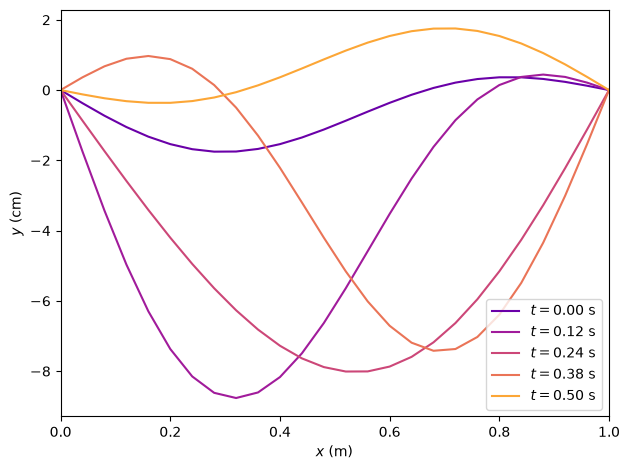

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from cmasher import get_sub_cmap

def wave_step(y_now, y_past, r):
    y_next = np.zeros_like(y_now)
    y_next[1:-1] = 2*y_now[1:-1] - y_past[1:-1] + r**2 * (y_now[2:] + y_now[:-2] - 2*y_now[1:-1])
    return y_now, y_next

L, timelength, c = 1, .5, 2

boundary_f = lambda x : np.sin(np.pi * x) + np.sin(2*np.pi * x)
boundary_g = lambda x : 0

dx = .04
N = 1 + int(round(L / dx))
xlin = np.linspace(0, L, N)

snapshot_times = (0, .125, .25, .375, .5)

dt = .02
timesteps = 1 + int(timelength/dt)

r = c * dt / dx

y_past = boundary_f(xlin)
y_now = np.zeros_like(y_past)

snapshot_steps = [int(round(time / dt)) for time in snapshot_times]

snapshots = {
    0.0 : y_past.copy()
}

for timestep in range(timesteps):
    y_past, y_now = wave_step(y_now, y_past, r)

    if timestep in snapshot_steps:
        snapshots[round(timestep * dt, 6)] = y_now.copy()

fig, ax = plt.subplots()

snapshot_colors = [c for c in get_sub_cmap("plasma", .2, .8, N=len(list(snapshots.keys()))).colors]
for (time, snapshot, snap_color) in zip(list(snapshots.keys()), list(snapshots.values()), snapshot_colors):
    ax.plot(xlin, snapshot, ls="solid", color=snap_color, label=f"$t = {time:.2f}$ s")

ax.set_xlim(left=np.min(xlin), right=np.max(xlin))

ax.set_xlabel(r"$x$ (m)")
ax.set_ylabel(r"$y$ (cm)")

ax.legend(loc="best")

fig.tight_layout()